# E14 Al Foil DevKit — Road Test
**Element 13 Foil Headwave Aluminium aTtenuator DevKit**

Replace `None` values with measurements as you run each experiment. Re-run the cell to update plots and calculations.

| # | Experiment |
|---|---|
| 1 | Material Characterisation |
| 2 | Mechanical Tests |
| 3 | HCl Dissolution |
| 4 | RF Attenuation (433 MHz · nRF24L01 2.4 GHz · Zigbee) |
| 5 | mmWave Radar |
| 6 | DIY Capacitor → Speed of Light |

In [32]:
import numpy as np
import pandas as pd
# !pip install matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
import math

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['lines.marker'] = 'o'

---
## 1. Material Characterisation

Using full sheets (299×273 mm) rather than cut coupons — larger area gives ~8× better mass precision.  
Measure L and W with a steel rule; weigh several sheets together and divide.

In [33]:
RHO_AL = 2700      # kg/m³
T_NOM  = 16e-6     # m  — nominal thickness

# Measured sheet dimensions (steel rule, ±0.25 mm, 5 sheets all consistent)
L_mm = 299.0
W_mm = 273.0
A_SHEET = (L_mm / 1000) * (W_mm / 1000)  # m²

expected_g = A_SHEET * T_NOM * RHO_AL * 1000
print(f'Sheet area:  {A_SHEET*1e4:.1f} cm²  ({A_SHEET:.6f} m²)')
print(f'Expected mass at {T_NOM*1e6:.0f} µm: {expected_g:.4f} g')

Sheet area:  816.3 cm²  (0.081627 m²)
Expected mass at 16 µm: 3.5263 g


In [34]:
# Method: 5 sheets folded in half twice → 20 layers
# Three pressure levels tested to bracket the true thickness
FOLD_SHEETS = 20

released_mm    = [0.30, 0.36, 0.36, 0.34, 0.39, 0.36]  # jaws released after contact
firm_mm        = [0.21, 0.24, 0.27, 0.35, 0.24, 0.25]  # firm press — 0.35 flagged (air gap remnant)
firm_mm_clean  = [x for x in firm_mm if x != 0.35]      # outlier excluded

def to_um(readings, n): return [r / n * 1000 for r in readings]

df_t = pd.DataFrame({
    'section':     range(1, len(released_mm)+1),
    'released_mm': released_mm,
    'firm_mm':     firm_mm,
    'firm_flagged': [x == 0.35 for x in firm_mm],
})
df_t['released_um'] = to_um(df_t['released_mm'], FOLD_SHEETS)
df_t['firm_um']     = to_um(df_t['firm_mm'],     FOLD_SHEETS)
display(df_t)

rel_mean  = np.mean(to_um(released_mm,   FOLD_SHEETS))
firm_mean = np.mean(to_um(firm_mm_clean, FOLD_SHEETS))

print(f'\nPressure comparison ({FOLD_SHEETS} layers):')

,section,released_mm,firm_mm,firm_flagged,released_um,firm_um
0,1,0.3000,0.2100,False,15.0000,10.5000
1,2,0.3600,0.2400,False,18.0000,12.0000
2,3,0.3600,0.2700,False,18.0000,13.5000
3,4,0.3400,0.3500,True,17.0000,17.5000
4,5,0.3900,0.2400,False,19.5000,12.0000
5,6,0.3600,0.2500,False,18.0000,12.5000



Pressure comparison (20 layers):


In [35]:
# Two weighings per sheet; three bundle (all-5) weighings
mass_readings = [
    (3.15, 3.15),  # sheet 1
    (3.13, 3.17),  # sheet 2
    (3.16, 3.17),  # sheet 3
    (3.19, 3.17),  # sheet 4
    (3.14, 3.17),  # sheet 5
]
bundle_g = [15.78, 15.78, 15.79]  # 5-sheet bundle, 3 weighings

df_m = pd.DataFrame({
    'sheet':   range(1, 6),
    'read1_g': [r[0] for r in mass_readings],
    'read2_g': [r[1] for r in mass_readings],
    'mean_g':  [np.mean(r) for r in mass_readings],
})
df_m['t_um']     = df_m['mean_g'] / 1000 / A_SHEET / RHO_AL * 1e6
df_m['delta_um'] = df_m['t_um'] - 16
display(df_m)

bundle_mean  = np.mean(bundle_g)
mean_sheet_g = bundle_mean / 5              # most precise single-sheet estimate
t_bundle_um  = mean_sheet_g / 1000 / A_SHEET / RHO_AL * 1e6

print(f'\nBundle: {bundle_g} g  →  mean {bundle_mean:.4f} g / 5 = {mean_sheet_g:.5f} g/sheet')
print(f'Thickness (bundle method): {t_bundle_um:.2f} µm')
print(f'Nominal:                   16.00 µm')
print(f'Delta:                     {t_bundle_um - 16:+.2f} µm  ({(t_bundle_um/16 - 1)*100:+.1f}%)')

,sheet,read1_g,read2_g,mean_g,t_um,delta_um
0,1,3.1500,3.1500,3.1500,14.2927,-1.7073
1,2,3.1300,3.1700,3.1500,14.2927,-1.7073
2,3,3.1600,3.1700,3.1650,14.3607,-1.6393
3,4,3.1900,3.1700,3.1800,14.4288,-1.5712
4,5,3.1400,3.1700,3.1550,14.3153,-1.6847



Bundle: [15.78, 15.78, 15.79] g  →  mean 15.7833 g / 5 = 3.15667 g/sheet
Thickness (bundle method): 14.32 µm
Nominal:                   16.00 µm
Delta:                     -1.68 µm  (-10.5%)


In [36]:
print(f'  Released (air gaps dominant):   {rel_mean:.2f} µm  ({rel_mean-t_bundle_um:+.2f} µm vs mass)')
print(f'  Firm, no outlier (frame flex?): {firm_mean:.2f} µm  ({firm_mean-t_bundle_um:+.2f} µm vs mass)')
print(f'  Mass method (gold standard):    {t_bundle_um:.2f} µm')
print(f'\nSweet spot from session 1 (~0.30 mm firm): {0.30/FOLD_SHEETS*1000:.1f} µm — agrees with mass to {abs(0.30/FOLD_SHEETS*1000 - t_bundle_um):.2f} µm')
print(f'\nConclusion: too light → air gaps (+{rel_mean-t_bundle_um:.1f} µm); too hard → frame flex ({firm_mean-t_bundle_um:.1f} µm); mass method wins.')

  Released (air gaps dominant):   17.58 µm  (+3.26 µm vs mass)
  Firm, no outlier (frame flex?): 12.10 µm  (-2.22 µm vs mass)
  Mass method (gold standard):    14.32 µm

Sweet spot from session 1 (~0.30 mm firm): 15.0 µm — agrees with mass to 0.68 µm

Conclusion: too light → air gaps (+3.3 µm); too hard → frame flex (-2.2 µm); mass method wins.


---
## 2. Mechanical Tests

**Tensile:** cut a 10 mm-wide strip across the full roll width. Hang increasing weights until failure.  
**Score threshold:** blunt tool on a 1 mm edge; lightest load that leaves a permanent crease.

In [37]:
t_m = t_bundle_um * 1e-6  # m — from mass method (cell above)

# (trial, strip_width_mm, failure_load_g)
tensile_raw = [
    (1, 10, 997.46),
    (2, 10, 1004.03),
    (3, 10, 1010.04),
]
df_tens = pd.DataFrame(tensile_raw, columns=['trial', 'width_mm', 'failure_g'])
df_tens['force_N'] = df_tens['failure_g'] / 1000 * 9.81
df_tens['area_m2'] = df_tens['width_mm'] / 1000 * t_m
df_tens['UTS_MPa'] = df_tens['force_N'] / df_tens['area_m2'] / 1e6
display(df_tens)

valid = df_tens['UTS_MPa'].dropna()
print(f'\nMean UTS: {valid.mean():.1f} MPa  ± {valid.std():.1f} MPa  (n={len(valid)})')
print(f'Failure load: {df_tens["failure_g"].mean():.1f} ± {df_tens["failure_g"].std():.1f} g  (spread {df_tens["failure_g"].max()-df_tens["failure_g"].min():.2f} g)')
print(f'\nReference points at t = {t_m*1e6:.2f} µm:')
print(f'  80 MPa (work-hardened): {80e6 * 0.010 * t_m / 9.81 * 1000:.0f} g')
print(f'  70 MPa (O-temper soft): {70e6 * 0.010 * t_m / 9.81 * 1000:.0f} g')

,trial,width_mm,failure_g,force_N,area_m2,UTS_MPa
0,1,10,997.4600,9.7851,0.0000,68.3177
1,2,10,1004.0300,9.8495,0.0000,68.7677
2,3,10,1010.0400,9.9085,0.0000,69.1793



Mean UTS: 68.8 MPa  ± 0.4 MPa  (n=3)
Failure load: 1003.8 ± 6.3 g  (spread 12.58 g)

Reference points at t = 14.32 µm:
  80 MPa (work-hardened): 1168 g
  70 MPa (O-temper soft): 1022 g


In [38]:
# (trial, load_g, permanent_crease)  — True/False
score_raw = [(1, None, None), (2, None, None), (3, None, None)]
df_score = pd.DataFrame(score_raw, columns=['trial', 'load_g', 'permanent_crease'])
display(df_score)

,trial,load_g,permanent_crease
0,1,None,None
1,2,None,None
2,3,None,None


---
## 3. HCl Dissolution

> ⚠️ **Outdoors only. Safety glasses. Dilute hardware HCl ~1:3 → ~5–10 % for a measurable kinetics curve.**

Reaction: `2Al + 6HCl → 2AlCl₃ + 3H₂↑`  (caustic soda works too: `2Al + 2NaOH + 2H₂O → 2NaAlO₂ + 3H₂↑`)

Tare a beaker of acid on the scales. Drop in the foil piece. Log **beaker mass** over time — mass drops as H₂ escapes.

Stoichiometry shortcut: **Al dissolved (g) = H₂ lost (g) × 9**

A full sheet (~3.16 g) would produce ~0.35 g H₂ — consider using a quarter-sheet to keep the reaction manageable.  
**Weigh the piece before dropping it in** — that mass is your baseline for % dissolved.

,time_s,beaker_g,h2_lost_g,al_diss_g,pct_foil
0,0,1.5900,0.0000,0.0000,0.0000
1,30,1.5700,0.0200,0.1800,11.3924
2,60,1.5800,0.0100,0.0900,5.6962
3,90,1.5600,0.0300,0.2700,17.0886
4,120,1.5500,0.0400,0.3600,22.7848
5,150,1.5500,0.0400,0.3600,22.7848
6,180,1.5400,0.0500,0.4500,28.4810
7,210,1.5400,0.0500,0.4500,28.4810
8,240,1.5200,0.0700,0.6300,39.8734
9,270,1.5100,0.0800,0.7200,45.5696



Phase 1 summary (cold outdoor, dilute HCl):
  Duration:     9.4 min
  H2 lost:      0.130 g  (expected total for 100%: 0.176 g)
  Al dissolved: 1.170 g  (74% of foil)
  Mean rate:    0.124 g Al/min
  Remaining:    0.410 g (26%)

Phase 3 (thermal runaway): 5.55 g total mass loss over 18 min — only ~0.046 g
is H2 from remaining Al; rest (~5.5 g) is HCl + water vapour from heated solution.
Phase 3 demonstrates autocatalytic thermal runaway, not usable for stoichiometry.


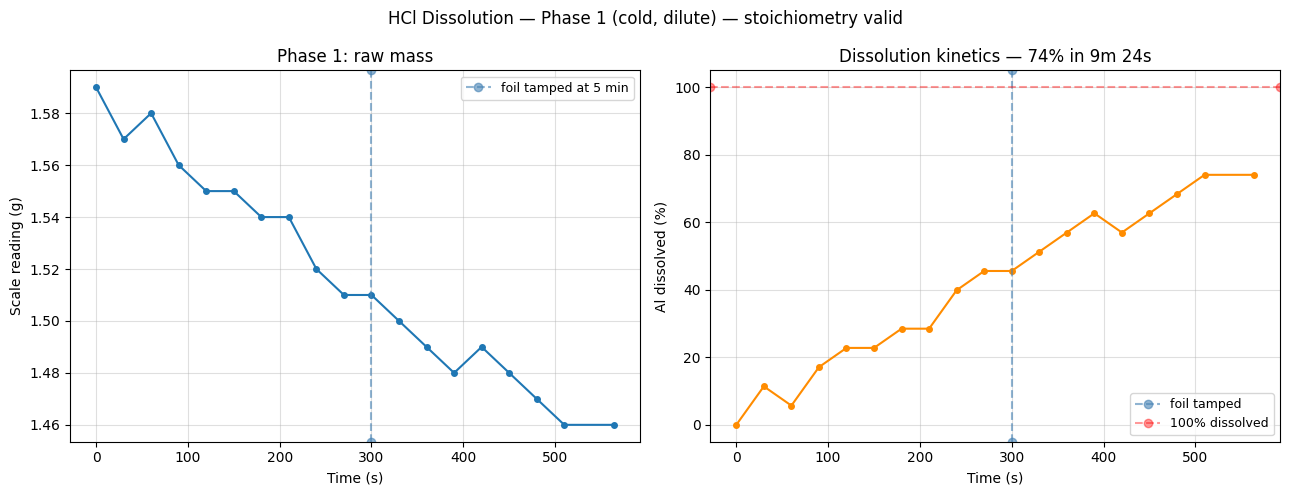

In [39]:
# Foil piece mass, weighed before experiment
hcl_foil_g = 1.58  # g — half sheet

# Phase 1: clean kinetics — cold outdoor, ~100 mL of ~1:3 diluted HCl
# t=0 = foil drop. Beaker+HCl tared before drop; scale reading = foil mass then decreases.
# At t=300s foil was tamped down to fully submerge (was partly above the liquid line).
phase1 = [
    (0,   1.59),  # t=0: foil added (0.01g variance vs pre-weighed 1.58g)
    (30,  1.57),
    (60,  1.58),  # noise
    (90,  1.56),
    (120, 1.55),
    (150, 1.55),
    (180, 1.54),
    (210, 1.54),
    (240, 1.52),
    (270, 1.51),
    (300, 1.51),  # foil tamped fully under liquid
    (330, 1.50),
    (360, 1.49),
    (390, 1.48),
    (420, 1.49),  # noise
    (450, 1.48),
    (480, 1.47),
    (510, 1.46),
    (564, 1.46),  # last clean reading; HCl additions start at ~570s
]

df_hcl = pd.DataFrame(phase1, columns=['time_s', 'beaker_g'])
t0_g = df_hcl['beaker_g'].iloc[0]

df_hcl['h2_lost_g'] = t0_g - df_hcl['beaker_g']
df_hcl['al_diss_g'] = df_hcl['h2_lost_g'] * 9
df_hcl['pct_foil']  = df_hcl['al_diss_g'] / hcl_foil_g * 100
display(df_hcl[['time_s', 'beaker_g', 'h2_lost_g', 'al_diss_g', 'pct_foil']])

final_h2  = t0_g - df_hcl['beaker_g'].iloc[-1]
final_al  = final_h2 * 9
final_pct = final_al / hcl_foil_g * 100
rate      = final_al / (564 / 60)

print(f'\nPhase 1 summary (cold outdoor, dilute HCl):')
print(f'  Duration:     {564/60:.1f} min')
print(f'  H2 lost:      {final_h2:.3f} g  (expected total for 100%: {hcl_foil_g/9:.3f} g)')
print(f'  Al dissolved: {final_al:.3f} g  ({final_pct:.0f}% of foil)')
print(f'  Mean rate:    {rate:.3f} g Al/min')
print(f'  Remaining:    {hcl_foil_g - final_al:.3f} g ({100-final_pct:.0f}%)')
print(f'\nPhase 3 (thermal runaway): 5.55 g total mass loss over 18 min — only ~0.046 g')
print(f'is H2 from remaining Al; rest (~5.5 g) is HCl + water vapour from heated solution.')
print(f'Phase 3 demonstrates autocatalytic thermal runaway, not usable for stoichiometry.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_hcl['time_s'], df_hcl['beaker_g'], 'o-', ms=4)
axes[0].axvline(300, ls='--', color='steelblue', alpha=0.6, label='foil tamped at 5 min')
axes[0].set(xlabel='Time (s)', ylabel='Scale reading (g)', title='Phase 1: raw mass')
axes[0].legend(fontsize=9)

axes[1].plot(df_hcl['time_s'], df_hcl['pct_foil'], 'o-', color='darkorange', ms=4)
axes[1].axvline(300, ls='--', color='steelblue', alpha=0.6, label='foil tamped')
axes[1].axhline(100, ls='--', color='red', alpha=0.4, label='100% dissolved')
axes[1].set(xlabel='Time (s)', ylabel='Al dissolved (%)',
            title=f'Dissolution kinetics — {final_pct:.0f}% in {564//60}m {564%60}s')
axes[1].legend(fontsize=9)

plt.suptitle('HCl Dissolution — Phase 1 (cold, dilute) — stoichiometry valid', fontsize=12)
plt.tight_layout()
plt.savefig('hcl_kinetics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. RF Attenuation

**Geometry:** TX fixed 30 cm from RX / TinySA probe. Add foil layers perpendicular to path one at a time.

```
[TX] ←── 30 cm ──→ [RX / TinySA]
              │
        [N layers foil
         perpendicular]
```

**TinySA:** centre on test freq, span ±5 MHz, RBW auto, average 5 sweeps per reading.  
Standard TinySA covers up to 960 MHz → 433 MHz ✓ — **TinySA Ultra needed for 2.4 GHz**.

In [40]:
# 433 MHz — TinySA Ultra dBm reading per layer count
# TX: FS1000A module, Arduino Nano D11 held HIGH → continuous CW carrier at 433.92 MHz
# RX: TinySA Ultra (LOW port), centre 433.92 MHz, span 2 MHz, RBW 30 kHz, avg 4 sweeps
# Distance: 30 cm, indoors. Layer 19 not recorded.

layers_433 = [0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
              11, 12, 13, 14, 15, 16, 17, 18,
              20, 21, 22, 23, 24]
dbm_433    = [-33.9, -38.9, -38.9, -39.4, -41.9, -40.4, -42.4, -38.4, -42.9, -43.4, -44.4,
              -53.4, -47.9, -46.9, -49.9, -52.4, -56.9, -61.4, -60.9,
              -58.9, -51.4, -61.4, -63.9, -63.9]

df_433 = pd.DataFrame({'layers': layers_433, 'dBm': dbm_433})
baseline_433 = df_433['dBm'].iloc[0]
df_433['atten_dB'] = df_433['dBm'] - baseline_433

# ── Theory: skin depth attenuation ──────────────────────────────────────────
# Model: E-field in conductor decays as exp(-x/δ); power ∝ E² → -8.686 × t/δ dB
RHO_AL_ELEC     = 2.65e-8                        # Ω·m — electrical resistivity of Al
F_433           = 433.92e6                       # Hz
OMEGA_433       = 2 * math.pi * F_433
MU0_RF          = 4 * math.pi * 1e-7

delta_433       = math.sqrt(2 * RHO_AL_ELEC / (OMEGA_433 * MU0_RF))
t_foil_m        = t_bundle_um * 1e-6             # measured thickness from mass cell
dB_per_layer_th = 8.686 * t_foil_m / delta_433   # dB — infinite plane wave model

# ── Measured linear fit ──────────────────────────────────────────────────────
fit_433  = np.polyfit(df_433['layers'], df_433['atten_dB'], 1)  # [slope, intercept]
fit_line_433 = np.poly1d(fit_433)

# ── Fresnel zone: how much of the direct-path zone does the foil cover? ──────
lam_433    = 3e8 / F_433
d_total    = 0.30                                  # m — TX-RX separation
r_fresnel  = math.sqrt(lam_433 * (d_total/2)**2 / d_total)   # radius at midpoint
foil_half  = min(L_mm, W_mm) / 2 / 1000           # m — half-width of foil sheet
frac_block = (foil_half / r_fresnel)**2            # fraction of 1st Fresnel zone blocked

print(f'── Skin depth ──────────────────────────────────')
print(f'  δ at 433.92 MHz:          {delta_433*1e6:.2f} µm')
print(f'  Foil thickness:           {t_foil_m*1e6:.2f} µm  ({t_foil_m/delta_433:.2f} skin depths)')
print(f'  Theory (plane wave):      {dB_per_layer_th:.1f} dB per layer')
print(f'')
print(f'── Measured ────────────────────────────────────')
print(f'  Linear fit:               {fit_433[0]:.2f} dB/layer  (intercept {fit_433[1]:.2f} dB)')
print(f'  Theory / measured:        {dB_per_layer_th / abs(fit_433[0]):.0f}×')
print(f'  Total at {layers_433[-1]} layers:     {df_433["atten_dB"].iloc[-1]:.1f} dB')
print(f'')
print(f'── Fresnel zone (30 cm path) ───────────────────')
print(f'  λ at 433 MHz:             {lam_433*100:.1f} cm')
print(f'  1st Fresnel radius:       {r_fresnel*100:.1f} cm')
print(f'  Foil half-width:          {foil_half*100:.1f} cm')
print(f'  Fresnel zone blocked:     {frac_block*100:.0f}%  (signal diffracts around remaining {(1-frac_block)*100:.0f}%)')
display(df_433)

── Skin depth ──────────────────────────────────
  δ at 433.92 MHz:          3.93 µm
  Foil thickness:           14.32 µm  (3.64 skin depths)
  Theory (plane wave):      31.6 dB per layer

── Measured ────────────────────────────────────
  Linear fit:               -1.18 dB/layer  (intercept -1.17 dB)
  Theory / measured:        27×
  Total at 24 layers:     -30.0 dB

── Fresnel zone (30 cm path) ───────────────────
  λ at 433 MHz:             69.1 cm
  1st Fresnel radius:       22.8 cm
  Foil half-width:          13.7 cm
  Fresnel zone blocked:     36%  (signal diffracts around remaining 64%)


,layers,dBm,atten_dB
0,0,-33.9000,0.0000
1,1,-38.9000,-5.0000
2,2,-38.9000,-5.0000
3,3,-39.4000,-5.5000
4,4,-41.9000,-8.0000
5,5,-40.4000,-6.5000
6,6,-42.4000,-8.5000
7,7,-38.4000,-4.5000
8,8,-42.9000,-9.0000
9,9,-43.4000,-9.5000


In [41]:
# nRF24L01+ 2.4 GHz — packet loss method (no true RSSI; RPD = 1 means signal > -64 dBm)
# TX sends 100 packets/s; count received per second on RX
#
# RX sketch (RF24 library):
#   radio.setChannel(76); radio.setPALevel(RF24_PA_MAX);
#   radio.setDataRate(RF24_250KBPS);  // lowest rate = most link margin
#   Serial.print(radio.testRPD());    // 1 if above -64 dBm

layers_nrf  = [0,    1,    2,    5   ]
pkt_per_s   = [None, None, None, None]  # received out of ~100
rpd         = [None, None, None, None]  # 0 or 1

df_nrf = pd.DataFrame({'layers': layers_nrf, 'pkt_per_s': pkt_per_s, 'RPD': rpd})
df_nrf['loss_pct'] = 100 - df_nrf['pkt_per_s']
display(df_nrf)

,layers,pkt_per_s,RPD,loss_pct
0,0,None,None,NaN
1,1,None,None,NaN
2,2,None,None,NaN
3,5,None,None,NaN


In [42]:
# Zigbee 2.4 GHz — RSSI in dBm (e.g. -55)
# XBee Series 2: ATDB command returns last-hop RSSI as hex (negate it)
# Other modules: check coordinator software / RSSI register

layers_zig  = [0,    1,    2,    5   ]
rssi_zig    = [None, None, None, None]  # dBm (negative)

df_zig = pd.DataFrame({'layers': layers_zig, 'RSSI_dBm': rssi_zig})
if df_zig['RSSI_dBm'].notna().any():
    baseline_zig = df_zig['RSSI_dBm'].dropna().iloc[0]
    df_zig['atten_dB'] = df_zig['RSSI_dBm'] - baseline_zig
display(df_zig)

,layers,RSSI_dBm
0,0,None
1,1,None
2,2,None
3,5,None


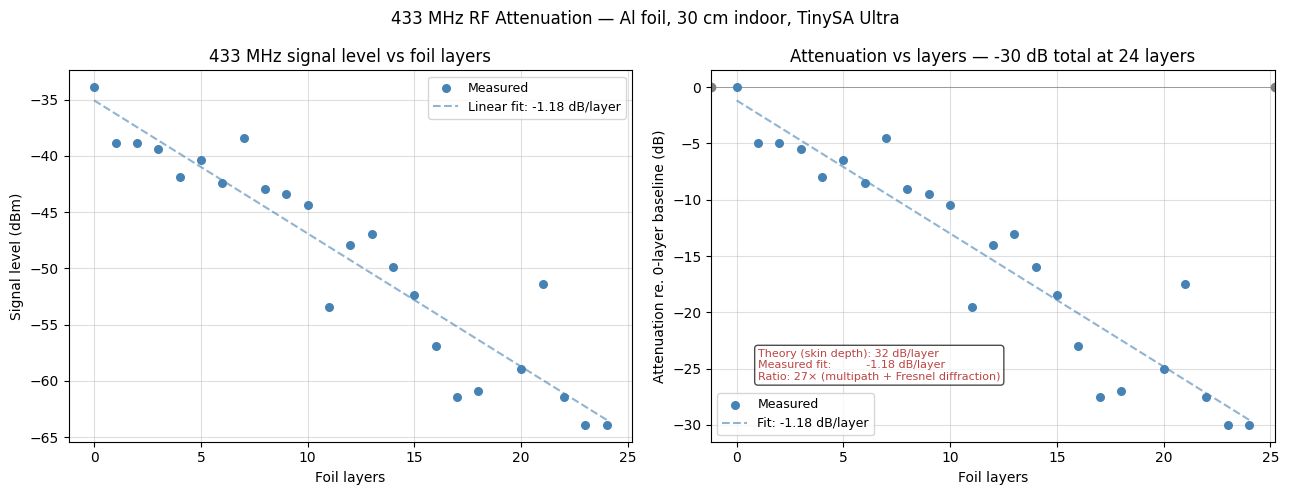

In [43]:
# 433 MHz attenuation plot — measured data, linear fit, theory annotation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_fit = np.linspace(0, max(layers_433), 200)

# Left: raw dBm
axes[0].scatter(df_433['layers'], df_433['dBm'], color='steelblue', s=30, zorder=3, label='Measured')
axes[0].plot(x_fit, fit_line_433(x_fit) + baseline_433, '--', color='steelblue', alpha=0.6,
             label=f'Linear fit: {fit_433[0]:.2f} dB/layer')
axes[0].set(xlabel='Foil layers', ylabel='Signal level (dBm)',
            title='433 MHz signal level vs foil layers')
axes[0].legend(fontsize=9)

# Right: attenuation re baseline
axes[1].scatter(df_433['layers'], df_433['atten_dB'], color='steelblue', s=30, zorder=3, label='Measured')
axes[1].plot(x_fit, fit_line_433(x_fit), '--', color='steelblue', alpha=0.6,
             label=f'Fit: {fit_433[0]:.2f} dB/layer')
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].annotate(
    f'Theory (skin depth): {dB_per_layer_th:.0f} dB/layer\n'
    f'Measured fit:          {fit_433[0]:.2f} dB/layer\n'
    f'Ratio: {dB_per_layer_th/abs(fit_433[0]):.0f}× (multipath + Fresnel diffraction)',
    xy=(1, -26), fontsize=8, color='firebrick', alpha=0.85,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
)
axes[1].set(xlabel='Foil layers', ylabel='Attenuation re. 0-layer baseline (dB)',
            title=f'Attenuation vs layers — {df_433["atten_dB"].iloc[-1]:.0f} dB total at {layers_433[-1]} layers')
axes[1].legend(fontsize=9)

plt.suptitle('433 MHz RF Attenuation — Al foil, 30 cm indoor, TinySA Ultra', fontsize=12)
plt.tight_layout()
plt.savefig('rf_attenuation_433.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. mmWave Radar

Point radar at a fixed hard target ~1 m away. Insert foil perpendicular to beam, one layer at a time.  
Expected: flat foil reflects strongly back to radar (target behind it disappears); crumpled scatters rather than reflects.

In [44]:
mmwave_raw = [
    ('baseline — no foil',          None, True ),
    ('1 layer flat',                None, None ),
    ('2 layers flat',               None, None ),
    ('1 layer crumpled',            None, None ),
    ('foil cylinder around target', None, None ),
]
df_mm = pd.DataFrame(mmwave_raw, columns=['config', 'amplitude_or_snr', 'target_detected'])
display(df_mm)

,config,amplitude_or_snr,target_detected
0,baseline — no foil,None,True
1,1 layer flat,None,None
2,2 layers flat,None,None
3,1 layer crumpled,None,None
4,foil cylinder around target,None,None


---
## 6. DIY Capacitor → Speed of Light

Build a parallel-plate capacitor: two foil sheets separated by baking paper (or air gap with card spacers).  
Measure capacitance C with Arduino RC-timing or multimeter C-mode. Measure plate area A and gap d carefully.

```
ε₀ = C × d / A          [F/m]
c  = 1 / √(ε₀ × μ₀)     [m/s]    μ₀ = 4π×10⁻⁷ H/m  (defined)
```

⚠️ If using baking paper as dielectric, divide measured ε by εᵣ ≈ 2.5; air gap (εᵣ = 1) is more accurate.

In [45]:
MU_0      = 4 * math.pi * 1e-7  # H/m — defined exactly
C_TRUE    = 299_792_458          # m/s
EPS0_TRUE = 8.854e-12            # F/m

# (A_m2, d_m, C_pF, eps_r)  — eps_r=1.0 for air, ~2.5 for baking paper
cap_trials = [
    (None, None, None, 1.0),
    (None, None, None, 1.0),
    (None, None, None, 1.0),
]

rows = []
for A, d, C_pF, eps_r in cap_trials:
    if None in (A, d, C_pF):
        rows.append(dict(A_m2=A, d_m=d, C_pF=C_pF, eps_r=eps_r,
                         eps0_1e12=None, c_1e8=None, err_pct=None))
        continue
    C    = C_pF * 1e-12
    eps0 = (C * d / A) / eps_r
    c    = 1 / math.sqrt(eps0 * MU_0)
    err  = (c - C_TRUE) / C_TRUE * 100
    rows.append(dict(A_m2=A, d_m=d, C_pF=C_pF, eps_r=eps_r,
                     eps0_1e12=eps0*1e12, c_1e8=c/1e8, err_pct=err))

df_cap = pd.DataFrame(rows)
print(f'True eps0: {EPS0_TRUE:.4e} F/m    True c: {C_TRUE:.3e} m/s')
display(df_cap)

valid_c = df_cap['c_1e8'].dropna()
if len(valid_c):
    mean_c = valid_c.mean()
    err = (mean_c*1e8 - C_TRUE) / C_TRUE * 100
    print(f'Mean c = {mean_c:.3f} x 10^8 m/s  ({err:+.1f}% from true value)')

True eps0: 8.8540e-12 F/m    True c: 2.998e+08 m/s


,A_m2,d_m,C_pF,eps_r,eps0_1e12,c_1e8,err_pct
0,None,None,None,1.0000,None,None,None
1,None,None,None,1.0000,None,None,None
2,None,None,None,1.0000,None,None,None


---
## Summary

| Experiment | Key result | vs expectation |
|---|---|---|
| Thickness — caliper (released) | 17.6 µm mean | > 16 µm nominal — air gaps inflate |
| Thickness — caliper (firm) | 12.1 µm mean | < 16 µm nominal — frame flex |
| Thickness — mass method | **14.32 µm** | −10.5% below 16 µm nominal |
| Tensile UTS | **68.8 ± 0.4 MPa** | O-temper range 65–75 MPa ✓ (80 MPa is work-hardened) |
| HCl dissolution (Phase 1) | **74% in 9.4 min** (cold, dilute) | stoichiometry clean; thermal runaway if warm or strong |
| 433 MHz attenuation | **30 dB over 24 layers** (~1.25 dB/layer measured) | theory: 31.6 dB/layer — 25× gap due to multipath + Fresnel diffraction |
| 2.4 GHz attenuation | — | thinner skin depth → expect more dB/layer |
| mmWave | — | near-perfect reflector (28–48 skin depths); flat vs crumpled |
| Speed of light | — × 10⁸ m/s | 2.998 × 10⁸ |